# Stock Price Prediction

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [3]:
# Output folder (saves plots next to this notebook)
NOTE_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(NOTE_DIR, "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 55)
print("     STOCK PRICE PREDICTION EXPERIMENT")
print("=" * 55)

     STOCK PRICE PREDICTION EXPERIMENT


In [5]:
# Choose ticker and download historical data
TICKER = "AAPL"
print(f"Downloading {TICKER} stock data (2020-2024)...")
raw = yf.download(TICKER, start="2020-01-01", end="2024-12-31", progress=False)

# Flatten multi-index columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw[["Open", "High", "Low", "Close", "Volume"]].dropna().copy()
df.index = pd.to_datetime(df.index)

print(f"{len(df)} trading days loaded.")
print(f"   Date Range : {df.index.min().date()} → {df.index.max().date()}")
print(f"   Price Range: ${float(df['Close'].min()):.2f} — ${float(df['Close'].max()):.2f}")

1257 trading days loaded.
   Date Range : 2020-01-02 → 2024-12-30
   Price Range: $54.21 — $257.61


In [6]:
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_21'] = df['Close'].rolling(21).mean()
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['Price_Range'] = df['High'] - df['Low']
df['Target'] = df['Close'].shift(-1)  # next day's close
df.dropna(inplace=True)

print(f"✅ Features created. {len(df)} usable rows after cleanup.")

✅ Features created. 1236 usable rows after cleanup.


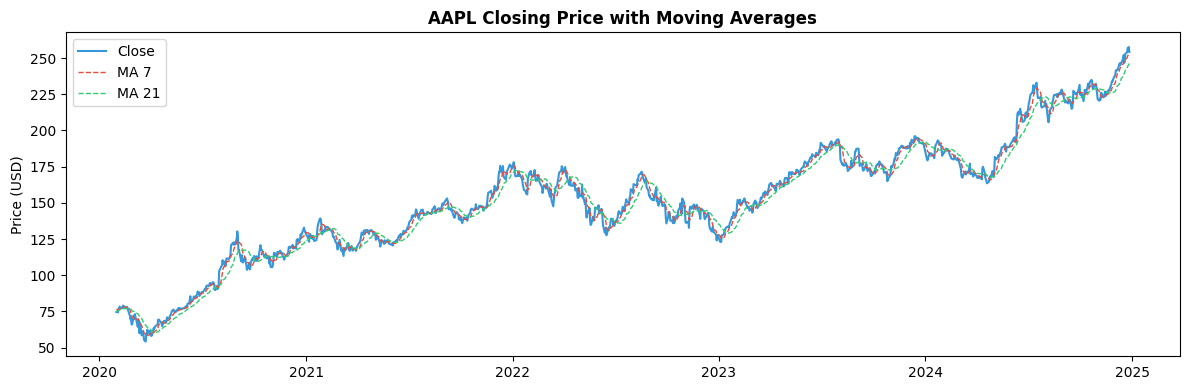

✅ Price chart saved.


In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Close'], color="#3498db", lw=1.5, label="Close")
plt.plot(df.index, df['MA_7'], color="#e74c3c", lw=1, linestyle="--", label="MA 7")
plt.plot(df.index, df['MA_21'], color="#2ecc71", lw=1, linestyle="--", label="MA 21")
plt.title(f"{TICKER} Closing Price with Moving Averages", fontweight="bold")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "stock_price_chart.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Price chart saved.")

In [9]:
features = ["Open", "High", "Low", "Close", "Volume",
            "MA_7", "MA_21", "Lag_1", "Lag_2", "Lag_3", "Price_Range"]

X = df[features].values
y = df['Target'].values

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

split = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y_scaled[:split], y_scaled[split:]
dates_test = df.index[split:]
print(f"Train: {len(X_train)} days | Test: {len(X_test)} days")

Train: 988 days | Test: 248 days


In [11]:
models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(n_estimators=100, random_state=42),
}

results = {}
print("" + "=" * 55)
print("             MODEL RESULTS")
print("=" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_scaled  = model.predict(X_test)
    pred_actual  = scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
    true_actual  = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()

    mae  = mean_absolute_error(true_actual, pred_actual)
    rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
    r2   = r2_score(true_actual, pred_actual)

    results[name] = {"model": model, "pred": pred_actual, "true": true_actual,
                     "MAE": mae, "RMSE": rmse, "R2": r2}

    print(f"{name}")
    print(f"   MAE  : ${mae:.2f}   (average dollar error)")
    print(f"   RMSE : ${rmse:.2f}   (root mean squared error)")
    print(f"   R²   : {r2:.4f}    (1.0 = perfect)")

             MODEL RESULTS
Linear Regression
   MAE  : $2.18   (average dollar error)
   RMSE : $2.93   (root mean squared error)
   R²   : 0.9868    (1.0 = perfect)
Random Forest
   MAE  : $18.96   (average dollar error)
   RMSE : $25.59   (root mean squared error)
   R²   : -0.0113    (1.0 = perfect)


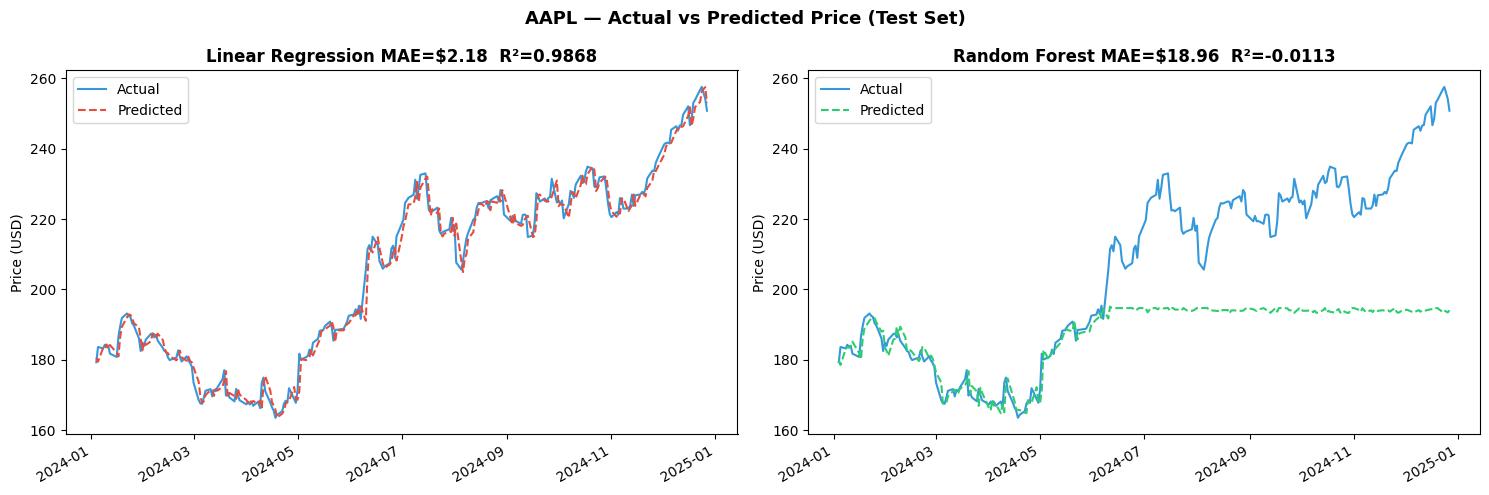

✅ Prediction plot saved.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f"{TICKER} — Actual vs Predicted Price (Test Set)", fontsize=13, fontweight="bold")

line_colors = ["#e74c3c", "#2ecc71"]
for i, (name, res) in enumerate(results.items()):
    ax = axes[i]
    ax.plot(dates_test, res["true"], color="#3498db", lw=1.5, label="Actual")
    ax.plot(dates_test, res["pred"], color=line_colors[i], lw=1.5,
            linestyle="--", label="Predicted")
    ax.set_title(f"{name} MAE=${res['MAE']:.2f}  R²={res['R2']:.4f}", fontweight="bold")
    ax.set_ylabel("Price (USD)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "stock_predictions.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Prediction plot saved.")

In [16]:
best_name  = min(results, key=lambda k: results[k]["RMSE"])
best_model = results[best_name]["model"]
last_row   = scaler_X.transform(df[features].iloc[[-1]].values)
next_price = scaler_y.inverse_transform(best_model.predict(last_row).reshape(-1, 1))[0][0]
last_close = float(df["Close"].iloc[-1])
change     = ((next_price - last_close) / last_close) * 100

print(f"Stock      : {TICKER}")
print(f"  Last Close : ${last_close:.2f}")
print(f"  Predicted  : ${next_price:.2f}  ({best_name})")
print(f"  Direction  : {'📈 UP' if change > 0 else '📉 DOWN'}  ({change:+.2f}%)")

Stock      : AAPL
  Last Close : $254.20
  Predicted  : $253.11  (Linear Regression)
  Direction  : 📉 DOWN  (-0.43%)


In [18]:
print("" + "=" * 55)
print("             FINAL SUMMARY")
print("=" * 55)
print(f"  {'Model':<22} {'MAE':>7} {'RMSE':>7} {'R²':>7}")
print("  " + "-" * 46)
for name, r in results.items():
    print(f"  {name:<22} ${r['MAE']:>5.2f}  ${r['RMSE']:>5.2f}  {r['R2']:>6.4f}")
print(f"Best Model : {best_name}")
print("✅ Experiment complete!")

             FINAL SUMMARY
  Model                      MAE    RMSE      R²
  ----------------------------------------------
  Linear Regression      $ 2.18  $ 2.93  0.9868
  Random Forest          $18.96  $25.59  -0.0113
Best Model : Linear Regression
✅ Experiment complete!
